# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 6 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [3]:
# Load selected group_id
import pickle
with open('group_id_selected_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_selected_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")

probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 


In [6]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [7]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


## No speed

AIC improvement of the model is: 0.0


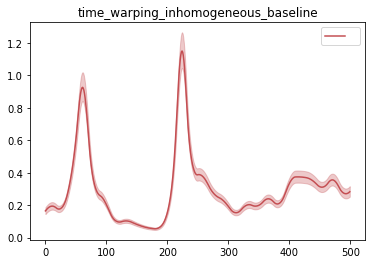

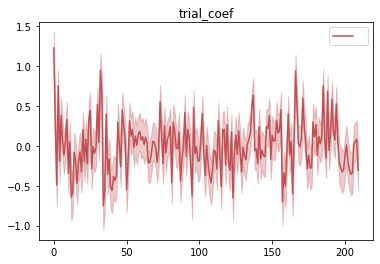

In [943]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)

baseline_aic = model.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Simple linear term of speed

AIC improvement of the model is: 19.525719638855662


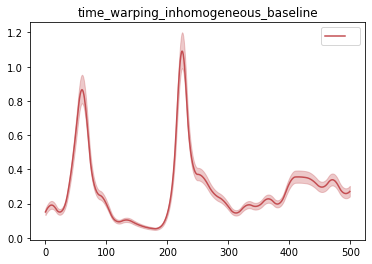

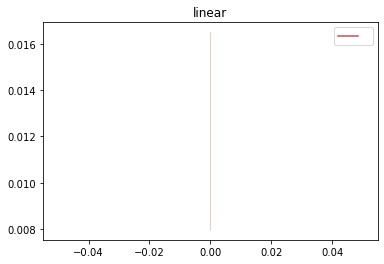

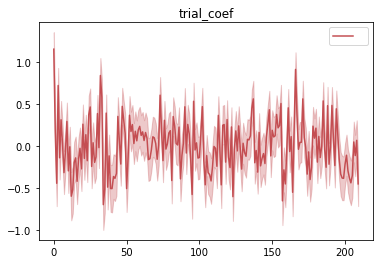

In [944]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Simple binary term of state

AIC improvement of the model is: 11.377192939427914


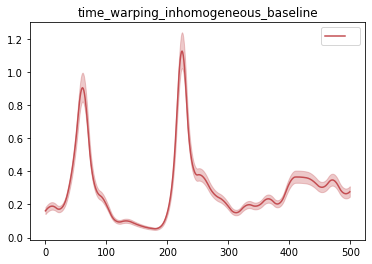

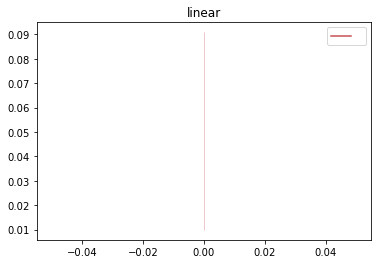

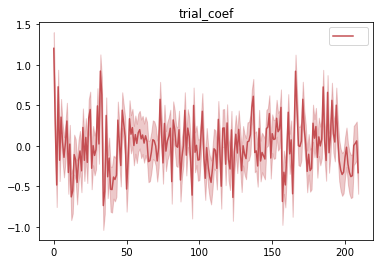

In [945]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
threshold = 1
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

AIC improvement of the model is: 1435.807935162331


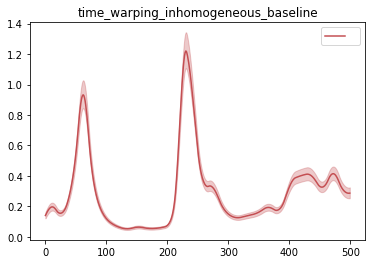

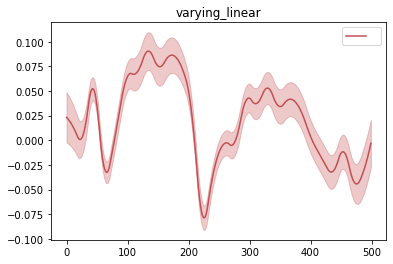

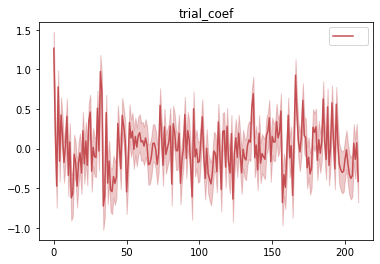

In [946]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying instantaneous binary term of state

AIC improvement of the model is: 1848.2833519917913


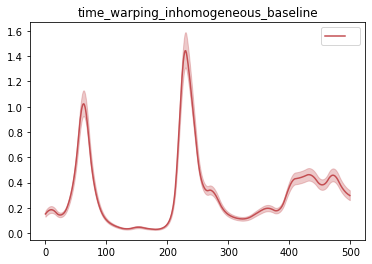

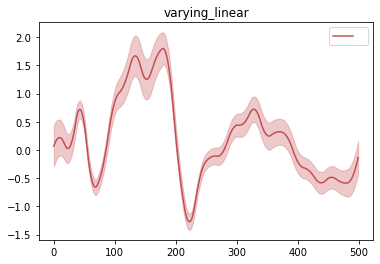

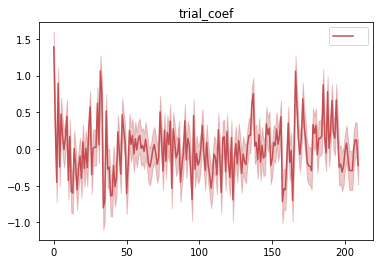

In [958]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying Trial-wise binary term of state

AIC improvement of the model is: 2363.687547071997


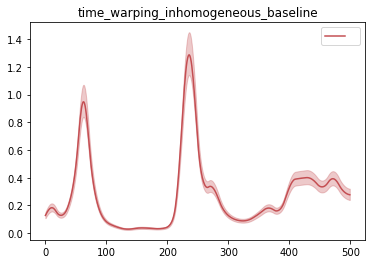

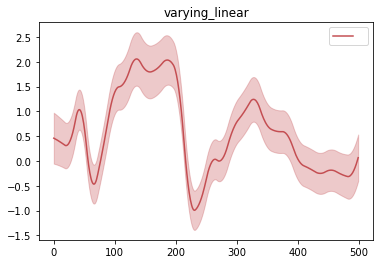

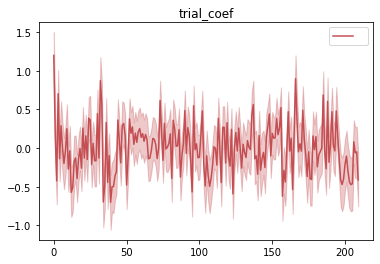

In [959]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

In [964]:
### 90% of the elements are the same in tria-wise state and instantaneous state
np.sum(trial_state == instantaneous_state)/(trial_state.shape[0]*trial_state.shape[1])

0.8979333333333334

## Two-way couping

AIC improvement of the model is: 173.63806043994555


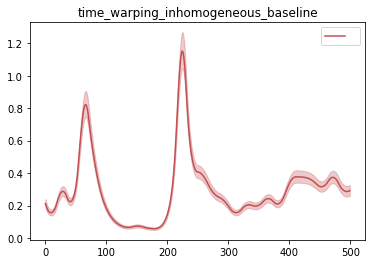

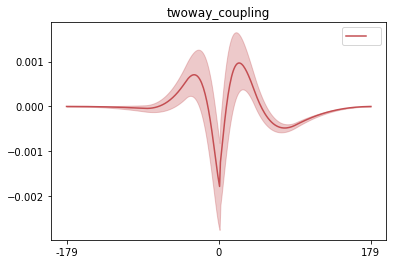

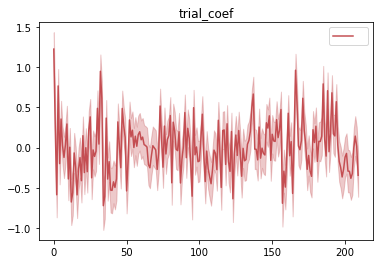

In [949]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

# Justify coupling effects should contain history effects with 1st/2nd order interaction terms or just 2nd order term of Lambda

## Baseline (no coupling)

In [982]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

baseline_aic = model_running.aic + model_stationary.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: -1.4551915228366852e-11


## Only cross-area coupling

In [983]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 4872.729694901893


## Both cross-area coupling and history

This is unstable when doing simulation

In [990]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':30, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 6566.487111910879


## With interaction in history effect

In [991]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8951.965682954215


## With only 2nd interaction in history effect

In [992]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8408.892742705568


## With both 1st and 2nd interaction in history effect

In [993]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 9470.023502450334


## With $\Lambda$ in history effect

In [994]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 7022.405490670702


## With $\Lambda^2$ refractory in history effect

In [1005]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8841.31411831532


## Interaction in all coupling effects

Not so good

In [996]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8419.418910917208


In [997]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8811.665204589794


# Mean firing rate

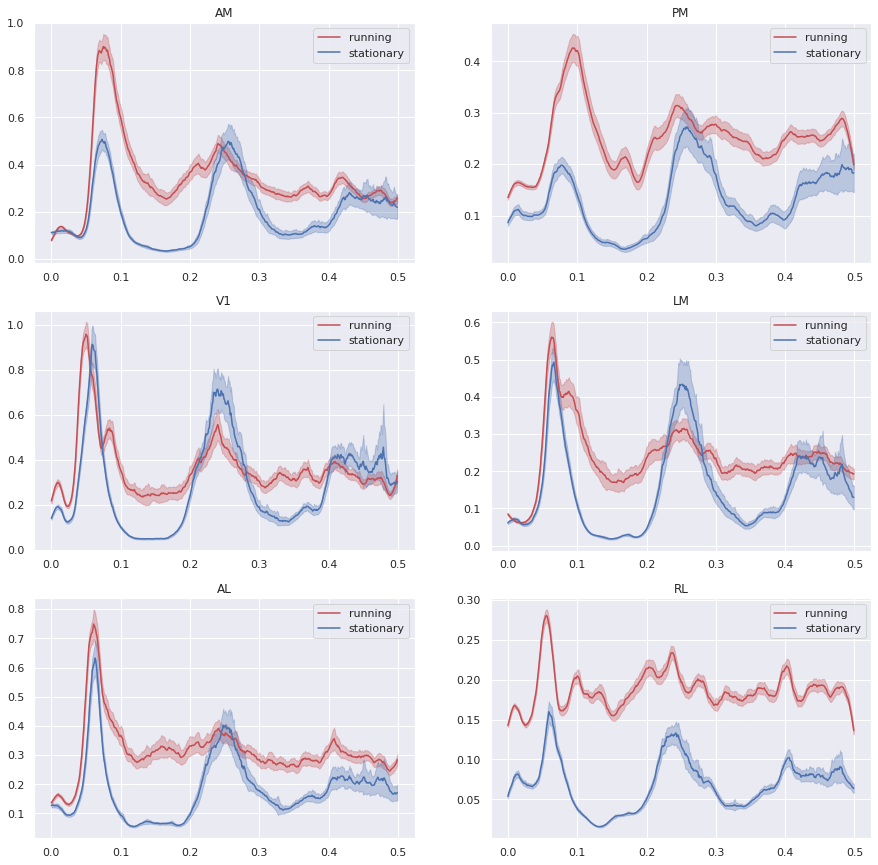

In [8]:
sns.set_theme()
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}
plt.subplots(figsize=(15,15))

for i, target_probe in enumerate(probe_list):
    plt.subplot(3, 2, i+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'r'
    label = 'running'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    plot_target = np.exp(model.log_lmbd)
    x = model.dataset.time_line
    y = plot_target.mean(axis=1)
    ci = plot_target.std(axis=1)/np.sqrt(plot_target.shape[1])
    color = 'b'
    label = 'stationary'
    plt.plot(x, y.squeeze(),label=label, color=color)
    plt.fill_between(x, (y-2*ci), (y+2*ci), color=color, alpha=.3)
    plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])

# Regularization (useless)

Useless, because we can't consider trial-wise features such as peak 1 peak 2 timing and trial-wise constant. 

In [126]:
##### Cell for CV
n_cv = 10
para_list = np.logspace(1, 3, 7)
all_considered_trial_idx = np.where(V1.stationary_trial_index)[0]

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 1e0

##### 
nlogli_rcd = np.zeros((len(para_list), n_cv))
template_for_kf = np.zeros((len(all_considered_trial_idx),1))

from sklearn.model_selection import KFold
kf = KFold(n_splits=n_cv)
kf.get_n_splits(template_for_kf)

for i, penalty in enumerate(tqdm(para_list)):
    j = 0
    for train_index, test_index in kf.split(template_for_kf):
        select_trials = np.full(V1.ntrial, False)
        select_trials[all_considered_trial_idx[train_index]] = True
        test_trials = np.full(V1.ntrial, False)
        test_trials[all_considered_trial_idx[test_index]] = True

        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
#         model.add_effect('trial_coef')
        for j, input_probe in enumerate(probe_list):
            model.add_effect('coupling', probe_list[j], **coupling_filter_params)
        model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
#         model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
        model.fit(target_probe, verbose=False, penalty=penalty)

        nlogli_rcd[i, j] = model.test(test_trials)
        j += 1

100%|██████████████████████████████████████| 7/7 [03:12<00:00, 27.50s/it]


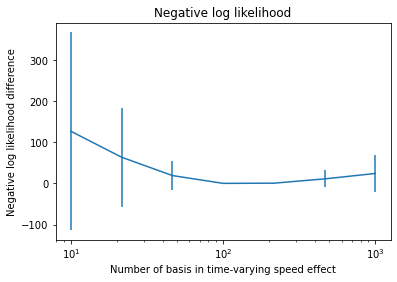

In [127]:
best_id = np.argmin(nlogli_rcd.mean(axis=1))
x = para_list
y = (nlogli_rcd-nlogli_rcd[best_id,:]).mean(axis=1)
dy = 2*(nlogli_rcd-nlogli_rcd[best_id,:]).std(axis=1)/np.sqrt(nlogli_rcd.shape[1])

plt.figure()
plt.errorbar(x, y, yerr=dy)
plt.title(f"Negative log likelihood")
plt.xlabel(f"Number of basis in time-varying speed effect")
plt.ylabel(f"Negative log likelihood difference")
plt.xscale('log')

# Fit six areas with 14 conditions

## Set up

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide couping filter hyperparameters

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

In [389]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_running.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

print(model_running.aic + model_stationary.aic)

56529.698990358615


## Fit

In [ ]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index] = GLM.get_ROI(function1, function2)
    statistics_filter[filter_index] = GLM.get_excursion_test(function1, function2, ROI_filter[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index] = GLM.get_ROI(function1, function2)
        statistics_filter[filter_index] = GLM.get_excursion_test(function1, function2, ROI_filter[filter_index])
        
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index] = GLM.get_ROI(function1, function2)
    statistics_output[filter_index] = GLM.get_excursion_test(function1, function2, ROI_output[filter_index])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index] = GLM.get_ROI(function1, function2)
        statistics_output[filter_index] = GLM.get_excursion_test(function1, function2, ROI_output[filter_index])

1it [00:31, 31.34s/it]

## Random shuffle (Excursion test)

In [1186]:
from GLM import get_statistics_null_mp
statistics_null_filter_new, statistics_null_output_new = get_statistics_null_mp(5, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=5


100%|██████████████████████████████████████| 5/5 [04:53<00:00, 58.77s/it]


In [25]:
# Load
with open('statistics_null_filter.pickle', 'rb') as handle:
    statistics_null_filter = pickle.load(handle)
with open('statistics_null_output.pickle', 'rb') as handle:
    statistics_null_output = pickle.load(handle)

In [ ]:
statistics_null_filter = GLM.merge_dict(statistics_null_filter, statistics_null_filter_new)
statistics_null_output = GLM.merge_dict(statistics_null_output, statistics_null_output_new)

In [1020]:
# Save statistics_null_filter and statistics_null_output
with open('statistics_null_filter.pickle', 'wb') as handle:
    pickle.dump(statistics_null_filter, handle)
with open('statistics_null_output.pickle', 'wb') as handle:
    pickle.dump(statistics_null_output, handle)

# Filters and inference on filters

In [67]:
pvalue_filter = {}
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        filter_index = i,j
        pvalue_filter[filter_index] = 1-np.sum( statistics_filter[filter_index][0]>statistics_null_filter[filter_index]) \
            /len(statistics_null_filter[filter_index])

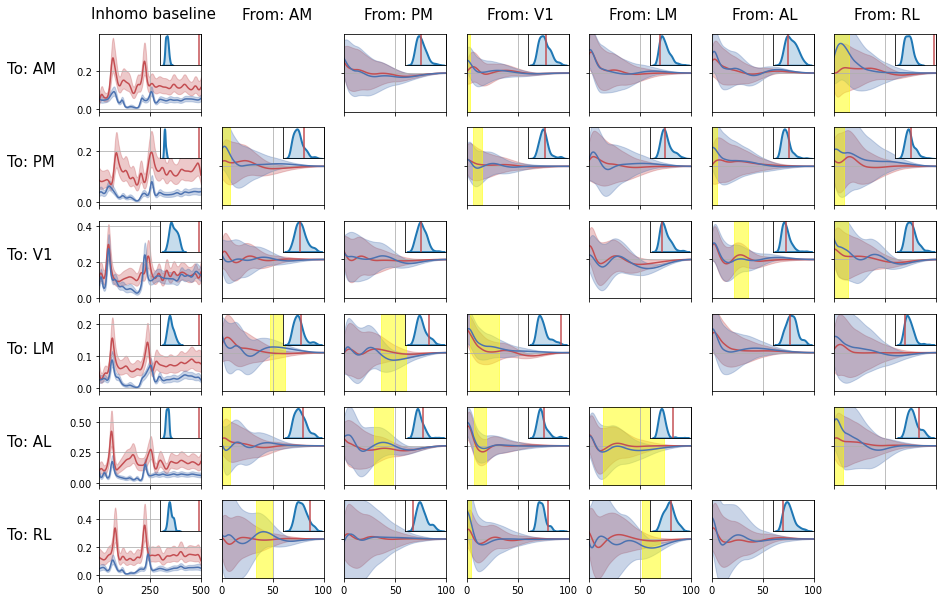

In [73]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = 100
filter_amp = 0.15
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])

        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            # Correct for different number of neurons in different areas
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        ins = ax.inset_axes([0.6,0.6,0.4,0.4])
        sns.kdeplot(statistics_null_filter[filter_index], linewidth=2, ax=ins, fill=True)
        ins.axvline(statistics_filter[filter_index], linewidth=1.5, color='r')
        ins.set_xticks([])
        ins.set_yticks([])
        ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.4*filter_length, 3.2*filter_amp, f'Inhomo baseline', fontsize=fontsize)

        if pvalue_filter[filter_index]<=0.4 and j!=-1:
            # change yellow to ROI
            stats_list = []
            for ii, ROI in enumerate(ROI_filter[filter_index]):
                function1 = stationary_filter[filter_index][0]
                function2 = running_filter[filter_index][0]
                diff = np.abs(function1 - function2)
                stats_list.append( np.sum(diff[ROI]) ) 
            temp = ROI_filter[filter_index][np.argmax(stats_list)]
            x = np.array([temp.min(), temp.max()])
            plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
                             color='yellow', alpha=.5)
#             ax.patch.set_alpha(0.3)
#             ax.set_facecolor('yellow')
            

# Output and inference on output

In [33]:
pvalue_output = {}
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        filter_index = i,j
        pvalue_output[filter_index] = 1-np.sum( statistics_output[filter_index][0]>statistics_null_output[filter_index]) \
            /len(statistics_null_output[filter_index])

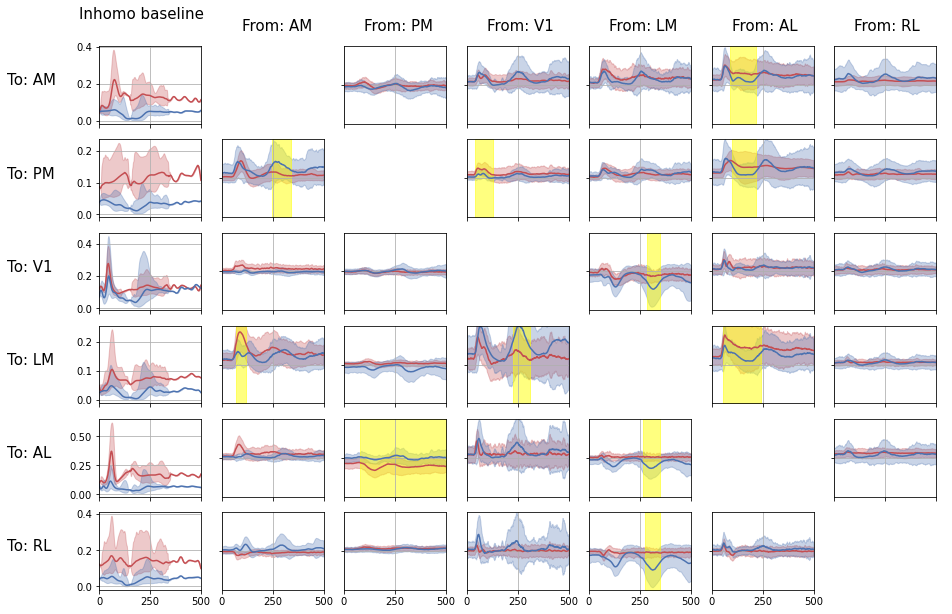

In [34]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15
filter_length = V1.nt
filter_amp = 1
trial_length = V1.nt

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_output[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, trial_length/2, trial_length])
            plt.xlim([0, trial_length])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-filter_amp, filter_amp])
            plt.yticks(color='w')
            plt.xticks([0, filter_length/2, filter_length])
            plt.xlim([0, filter_length])
            if i==0:
                plt.text(0.2*filter_length, 1.4*filter_amp, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-2.1*filter_length, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-4.5*filter_length, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0.2*filter_length, 3.8*filter_amp, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-0.2*filter_length, 0.55*filter_amp, f'Inhomo baseline', fontsize=fontsize)
            
        if pvalue_output[filter_index]<=0.2 and j!=-1:
            # change yellow to ROI
            stats_list = []
            for ii, ROI in enumerate(ROI_output[filter_index]):
                function1 = stationary_output[filter_index][0]
                function1 = running_output[filter_index][0]
                diff = np.abs(function1 - function2)
                stats_list.append( np.sum(diff[ROI]) ) 
            temp = ROI_output[filter_index][np.argmax(stats_list)]
            x = np.array([temp.min(), temp.max()])
            plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
                             color='yellow', alpha=.5)
#             ax.patch.set_alpha(0.3)
#             ax.set_facecolor('yellow')


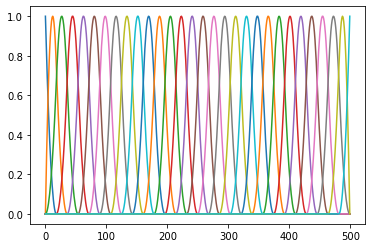

In [22]:
plt.plot(model.basis_list[0])

In [1170]:
stats_list = []
filter_index = 2,3
function1 = stationary_output[filter_index][0]
function2 = running_output[filter_index][0]
diff = 
for ii, ROI in enumerate(ROI_output[filter_index]):
    stats_list.append( np.sum(diff[ROI]) )
temp = ROI_output[filter_index][np.argmax(stats_list)]

# Graphical analysis

## KS test statistics (amount of information) graph

In [553]:
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
angle_list = [90, 65, 0, -90, -135, 165, 115]
dis_from_center = [1, 1, 0.5 ,1 ,1, 0.8, 1]

import networkx as nx
G = nx.DiGraph()
G.add_nodes_from([ name for name in name_dict.values() ])
pos_standard = {}
for i, angle in enumerate(angle_list):
    dis = dis_from_center[i]
    pos_standard[name_dict[i-1]] = dis*np.array([np.cos(angle/360*2*np.pi), 
                                                 np.sin(angle/360*2*np.pi)])

### all peaks

In [1089]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.35]
auto_pick = 1

probe_list = V1.selected_probes
running12 = {}
stationary12 = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running12[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running12[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary12[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary12[i,j] = filter_list[k]
        k += 1
    


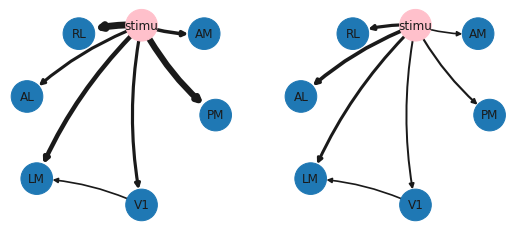

In [1090]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.1
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary12
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running12
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

### peak 1

In [1091]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.15]
auto_pick = 1

probe_list = V1.selected_probes
running1 = {}
stationary1 = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running1[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running1[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary1[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary1[i,j] = filter_list[k]
        k += 1


In [1092]:
def get_discrete_weight(weight, step1=0.2, step2=0.12, step3=0.08):
    if weight >=step1:
        return 4
    if weight >=step2:
        return 2.5
    elif weight >=step3:
        return 1.5
    else:
        return 0

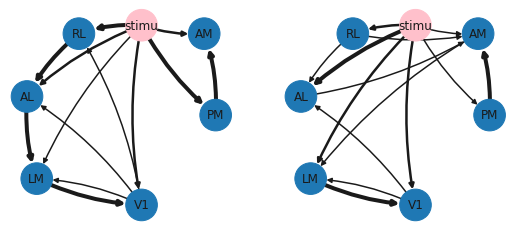

In [1093]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.07
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary1
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running1
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

In [1094]:
stationary1[2, -1][measure_type], running1[2, -1][measure_type]

(0.1460798437959825, 0.1310128024129824)

### peak 2

In [1095]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.15, 0.35]
auto_pick = 1

probe_list = V1.selected_probes
running2 = {}
stationary2 = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    running2[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running2[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    filter_list = model.get_filter_contribution(time_range=time_range, auto_pick=auto_pick)
    stationary2[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary2[i,j] = filter_list[k]
        k += 1


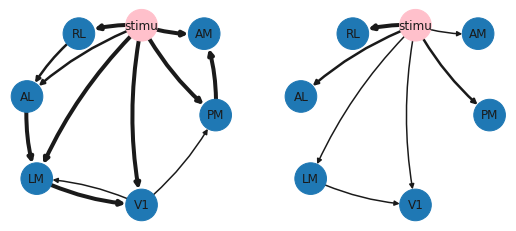

In [1096]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.07
plot_amp = 15

import networkx as nx

plt.subplots(figsize=(9,4))
plt.subplot(1,2,1)
to_plot_result = stationary2
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running2
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres and pair[0]!=pair[1]:
        weight = get_discrete_weight((value[measure_type]), step3=plot_thres)
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=weight)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)

color_list = ['#1f78b4' for node in G]
color_list[0] = 'pink'
nx.draw(G, pos_standard, with_labels=True, node_size=1000, width=weights, 
        connectionstyle='arc3, rad = 0.1', node_color=color_list)
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

# Simulation

Use stationary model list and running model list to do simulation

In [664]:
model_list = stationary_model_list
tau = 10
itrial = 0

import copy
import numpy.random
nneuron = len(model_list)
# Get three dimension matrix of coupling filters for better computing. 
max_histories = 1
max_histories_refractory = 1
nt = model_list[0].nt
# allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
coupling_mat = np.zeros((max_histories, nneuron, nneuron))
refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
baseline_mat = np.zeros((nt, nneuron))
spikes = np.zeros((nt, nneuron, 1))
probe2num = {}
for iprobe, probe in enumerate(probe_list):
    probe2num[probe] = iprobe

for ineuron in range(nneuron):
    assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
        "Only support inhomogeneous_baseline and coupling effects now!"
    model = model_list[ineuron]
    for ieffect, effect_type in enumerate(model.effect_type_list):
        
        if effect_type in ['inhomogeneous_baseline', ]:
            baseline_mat[:, ineuron] = model.filters[ieffect]
#             baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
#                                                                        baseline_mat[:, ineuron][:,None], 
#                                                                        model_list[0].shifts[itrial,:][None,:], 
#                                                                        model_list[0].nt).squeeze()
        elif effect_type in ['coupling']:
            nhistories = len(model.filters[ieffect])
            probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
            iprobe = probe2num[probe_name]
            if nhistories > max_histories:
                coupling_mat_old = coupling_mat
                coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                coupling_mat[-max_histories:, :, :] = coupling_mat_old
                max_histories = nhistories
            
            coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])
            
        elif effect_type in ['interaction']:
            nhistories = len(model.filters[ieffect])
            probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
            iprobe = probe2num[probe_name]
            if nhistories > max_histories_refractory:
                refractory_mat_old = refractory_mat
                refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                max_histories_refractory = nhistories
            refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

log_firing_rate = baseline_mat[:,:,np.newaxis]
spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

recent_spike_sum = spikes[0, :, 0]

for t in range(1, nt):
    recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
    nhistories = min(t, max_histories)
    temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    refractory *= recent_spike_sum/tau
    log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
#     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
    spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
    recent_spike_sum += spikes[t, :, 0]
    
log_firing_rate = log_firing_rate.squeeze()
spikes = spikes.squeeze()

In [712]:
###################
nepoch = 10
model_list = stationary_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

                elif effect_type in ['interaction']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories_refractory:
                        refractory_mat_old = refractory_mat
                        refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                        refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                        max_histories_refractory = nhistories
                    refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory *= recent_spike_sum/tau
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd[:, iepoch*model_list[0].ntrial + itrial, :] = spikes

Text(0.5, 1.0, 'Stationary experimental PSTH')

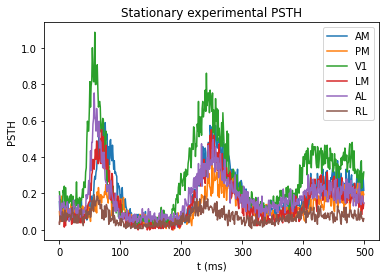

In [710]:
for i, probe_name in enumerate(name_list):
    plt.plot(stationary_model_list[i].output.mean(axis=1), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Stationary experimental PSTH')

Text(0.5, 1.0, 'Running experimental PSTH')

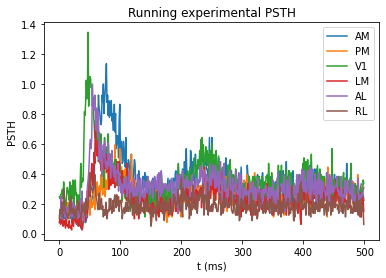

In [711]:
for i, probe_name in enumerate(name_list):
    plt.plot(running_model_list[i].output.mean(axis=1), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Running experimental PSTH')

Text(0.5, 1.0, 'Stationary condition model simulation PSTH')

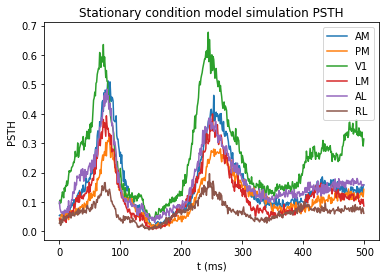

In [714]:
for i, probe_name in enumerate(name_list):
    plt.plot(spikes_rcd[:, :, i].mean(axis=1), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Stationary condition model simulation PSTH')

Text(0.5, 1.0, 'Running condition model simulation PSTH')

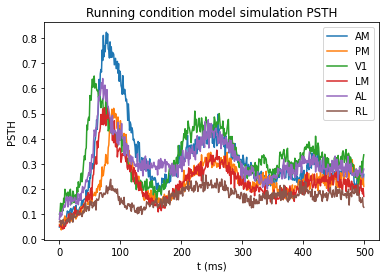

In [705]:
for i, probe_name in enumerate(name_list):
    plt.plot(spikes_rcd[:, :, i].mean(axis=1), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Running condition model simulation PSTH')

Text(0.5, 1.0, 'Stationary condition')

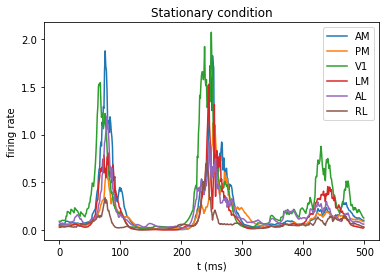

In [665]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition')

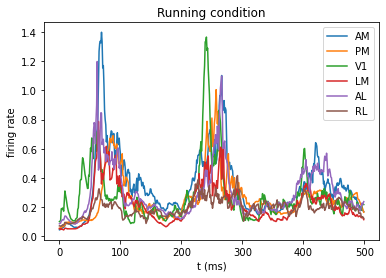

In [583]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

# Simulation with Lambda^2

In [715]:
penalty = 1e-5
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
# use_all = [True, True, False, False, False, True]
use_all = [False, False, False, False, False, False]

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=2, tau=tau)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=2, tau=tau)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
#     model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

6it [02:53, 28.99s/it]


In [730]:
###################
nepoch = 10
model_list = running_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction', 'refractory']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_params = np.zeros(nneuron)
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

            refractory_params[ineuron] = model.results.params[-1]
        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (recent_spike_sum/tau)**2
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory*refractory_params
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd[:, iepoch*model_list[0].ntrial + itrial, :] = spikes

Text(0.5, 1.0, 'Stationary experimental PSTH')

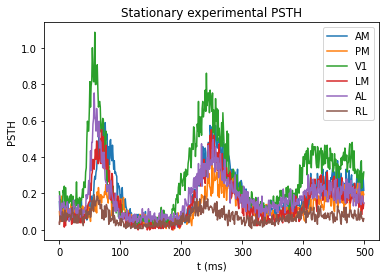

In [710]:
for i, probe_name in enumerate(name_list):
    plt.plot(utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Stationary experimental PSTH')

Text(0.5, 1.0, 'Running experimental PSTH')

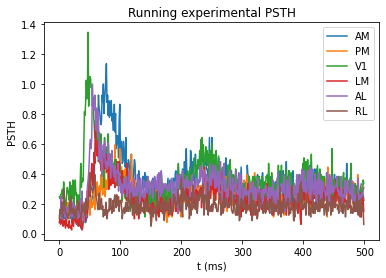

In [711]:
for i, probe_name in enumerate(name_list):
    plt.plot(utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Running experimental PSTH')

Text(0.5, 1.0, 'Stationary condition model simulation PSTH')

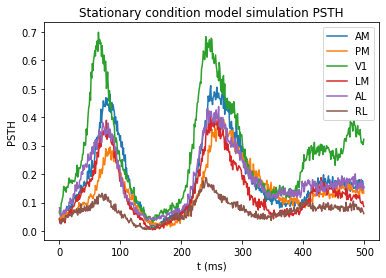

In [727]:
for i, probe_name in enumerate(name_list):
    plt.plot(utils.kernel_smoothing(spikes_rcd[:, :, i].mean(axis=1)), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Stationary condition model simulation PSTH')

Text(0.5, 1.0, 'Stationary condition')

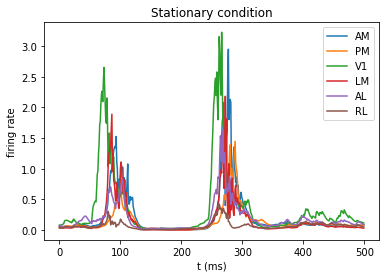

In [729]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition model simulation PSTH')

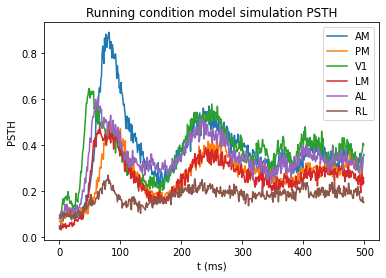

In [731]:
for i, probe_name in enumerate(name_list):
    plt.plot(utils.kernel_smoothing(spikes_rcd[:, :, i].mean(axis=1)）, label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('PSTH')
plt.title('Running condition model simulation PSTH')

Text(0.5, 1.0, 'Running condition')

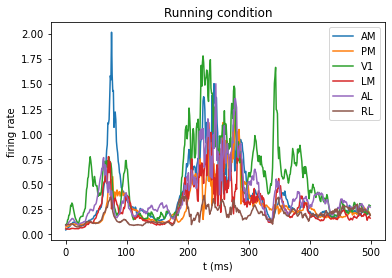

In [736]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

In [806]:
running_model_list[0].effect_type_list

['inhomogeneous_baseline',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'refractory']